# NetworkX: Communities & Substructures
*Discovering hidden modules, echo chambers, and localized cliques within complex networks.*

---

Welcome to **Notebook 3**, the final installment of our NetworkX series!

Now that you know how to build graphs (Notebook 1) and analyze their global properties and central nodes (Notebook 2), we are going to look for **patterns of organization**. 

In this notebook, we will cover:
1. **Local Structures:** Analyzing clustering coefficients, triadic closures, and finding cliques.
2. **Community Detection:** Running standard grouping algorithms like Girvan-Newman and Louvain.
3. **Evaluating Clusters:** Using **Modularity** to mathematically prove the strength of our communities.
4. **Advanced Plotting:** Creating beautiful, distinct, color-coded visual maps of our detected communities.
5. **Exercises:** Your turn to put these concepts into practice.


### 1. Setup & The Karate Club Graph
We will import NetworkX and Matplotlib. 

To make this tutorial authentic, we are going to use **Zachary's Karate Club graph**. This is a famous real-world dataset in network science representing the friendships between 34 members of a karate club. During the study, a conflict arose between the administrator ("John A") and the instructor ("Mr. Hi"), causing the club to split into two factions. We will use algorithms to see if we can detect these factions mathematically!


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# NetworkX provides a submodule for community algorithms
import networkx.algorithms.community as nx_comm

# Configure visual styling
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Load Zachary's Karate Club Graph
K = nx.karate_club_graph()

print(f"Nodes: {K.number_of_nodes()}")
print(f"Edges: {K.number_of_edges()}")


Nodes: 34
Edges: 78


### 2. Local Structures & Cliques
Before zooming out to entire communities, we can look at local node neighborhoods:
*   **Triangles:** How many triangles (3-node cliques) a node is part of. (If A knows B, and B knows C, does A know C?).
*   **Clustering Coefficient:** The fraction of a node's friends who are also friends with each other.
*   **Cliques:** A subset of nodes where *every* node is directly connected to *every* other node.


In [2]:
# 1. Number of Triangles per node (Showing top 5)
triangles = nx.triangles(K)
print("Triangles per node (Top 5):", dict(list(triangles.items())[:5]))

# 2. Average Clustering Coefficient
avg_clustering = nx.average_clustering(K)
print(f"\nAverage Network Clustering Coefficient: {avg_clustering:.4f}")

# 3. Find Maximal Cliques (Cliques that cannot be expanded)
cliques = list(nx.find_cliques(K))
largest_clique = max(cliques, key=len)

print(f"\nTotal maximal cliques found: {len(cliques)}")
print(f"The largest fully-connected clique contains {len(largest_clique)} members: {largest_clique}")


Triangles per node (Top 5): {0: 18, 1: 12, 2: 11, 3: 10, 4: 2}

Average Network Clustering Coefficient: 0.5706

Total maximal cliques found: 36
The largest fully-connected clique contains 5 members: [0, 1, 2, 3, 13]


### 3. Community Detection Algorithms
A community is a group of nodes with dense internal connections but sparse connections to the rest of the network.

NetworkX offers several ways to find these:
1. **Girvan-Newman Algorithm:** A divisive algorithm that iteratively removes the "bridges" (edges with the highest betweenness centrality) until the graph breaks apart into communities.
2. **Louvain Method:** An agglomerative algorithm that greedily groups nodes together to maximize a quality score called *modularity*. It is exceptionally fast and standard for large networks.


In [3]:
# --- 1. Girvan-Newman Algorithm ---
# It returns an iterator over partitions at different levels of removal
gn_generator = nx_comm.girvan_newman(K)
# Get the first level of splits (usually splits into 2 main communities)
gn_communities = next(gn_generator)

print("Girvan-Newman Communities:")
for i, comm in enumerate(gn_communities):
    print(f"Community {i+1}: {sorted(list(comm))}")

print("\n" + "="*50 + "\n")

# --- 2. Louvain Method ---
# Returns a list of sets, each representing a community
louvain_communities = nx_comm.louvain_communities(K, seed=42)

print("Louvain Communities:")
for i, comm in enumerate(louvain_communities):
    print(f"Community {i+1}: {sorted(list(comm))}")


Girvan-Newman Communities:
Community 1: [0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21]
Community 2: [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


Louvain Communities:
Community 1: [1, 2, 3, 7, 12, 13]
Community 2: [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
Community 3: [24, 25, 28, 31]
Community 4: [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]


### 4. Evaluating Cluster Quality (Modularity)
How do we know if our algorithm found *real* communities, or just grouped random nodes together? We use **Modularity**.
*   **Modularity ($Q$):** Measures the density of links inside communities compared to a randomized null model.
*   **Scale:** $Q$ ranges from -0.5 to 1.0. 
    * Scores $< 0$ mean worse than random.
    * Scores around $0.3 - 0.7$ usually indicate strong, distinct community structure.


In [4]:
# Calculate Modularity for both partition methods
mod_gn = nx_comm.modularity(K, gn_communities)
mod_louvain = nx_comm.modularity(K, louvain_communities)

print(f"Modularity Score (Girvan-Newman - 2 Factions): {mod_gn:.4f}")
print(f"Modularity Score (Louvain - Multi-Factions): {mod_louvain:.4f}")

# The Louvain method naturally found a partition with a higher modularity score!


Modularity Score (Girvan-Newman - 2 Factions): 0.3477
Modularity Score (Louvain - Multi-Factions): 0.4266


### 5. Advanced Visualizations: Mapping Communities to Colors
Let's visually verify the communities found by the **Louvain** algorithm. We will assign a unique color to each community and plot the network.


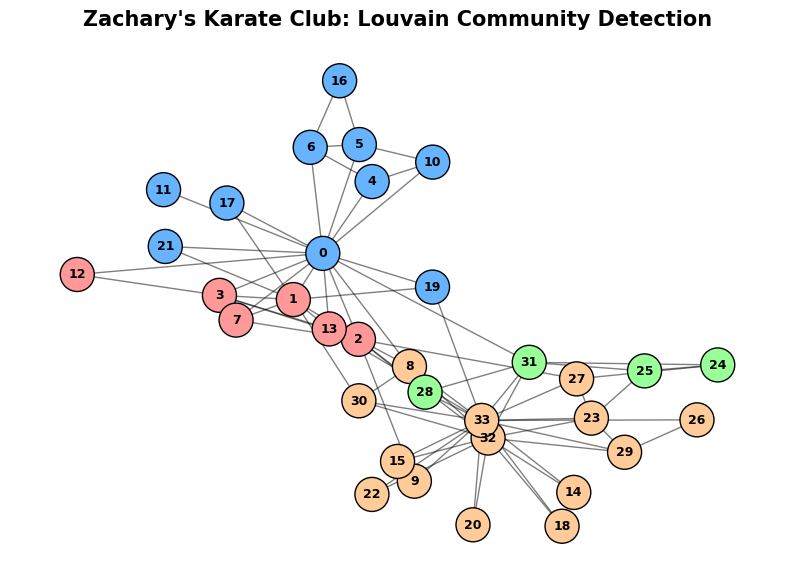

In [5]:
# Create a color map for the Louvain communities
community_color_map = {}
colors = ["#ff9999", "#66b3ff", "#99ff99", "#ffcc99", "#c2c2f0"] # Nice pastel palette

# Assign a specific color to each node based on its community
for idx, comm in enumerate(louvain_communities):
    for node in comm:
        community_color_map[node] = colors[idx % len(colors)]

# Make sure the colors list matches the exact order of K.nodes()
node_colors = [community_color_map[node] for node in K.nodes()]

# Setup layout
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(K, seed=42)

# Draw the network
nx.draw_networkx_nodes(K, pos, node_color=node_colors, node_size=600, edgecolors="black", linewidths=1.0)
nx.draw_networkx_edges(K, pos, alpha=0.5)
nx.draw_networkx_labels(K, pos, font_size=9, font_weight="bold")

plt.title("Zachary's Karate Club: Louvain Community Detection", fontsize=15, fontweight="bold")
plt.axis("off")
plt.show()


---
### 6. Exercises
Now it's your turn to practice detecting and visualizing communities!

#### Exercise 1: Exploring Les Misérables
NetworkX provides a co-appearance network of characters in the novel *Les Misérables*.
1. Load the graph: `LM = nx.les_miserables_graph()`.
2. Find the total number of connected components.
3. Compute the **Average Clustering Coefficient** of the network.


In [6]:
# Write your Exercise 1 code here:


#### Exercise 2: Louvain Partitioning on Les Misérables
1. Using the `LM` graph, run the **Louvain** algorithm to find character communities.
2. How many distinct communities did the algorithm find?
3. What is the **Modularity** score of this partition? Is it considered a "strong" community structure?


In [7]:
# Write your Exercise 2 code here:


#### Exercise 3: Visualizing the Factions
1. Plot the `LM` graph.
2. Color each node according to its Louvain community assignment (similar to how we did it for the Karate Club).
3. Use `nx.spring_layout` to space out the characters.


In [8]:
# Write your Exercise 3 code here:
